# Afrobeat vs. Western Music - A Data-Driven Analysis



# Introduction
African music, particularly Afrobeats, has experienced significant global growth over the past decade. Artists like Burna Boy, Omah Lay, and Ruger have brought African sounds to international audiences, generating millions of streams across platforms such as Spotify.
Despite this rising visibility, it remains unclear whether this growth is fully reflected in streaming performance and platform dynamics. This raises an important question: do the underlying data support the global narrative of Afrobeats’ success, or is there a gap between musical characteristics and streaming outcomes?
This project uses Spotify audio feature data to compare Afrobeats with selected Western genres. The goal is to examine whether differences in musical characteristics ,such as danceability, energy, valence, and tempo , help explain variations in streaming popularity.
In an increasingly data-driven music industry, understanding how audio features relate to performance is essential for platforms, labels, and marketing strategies.

# Research Questions

**Danceability & Popularity**

Does higher danceability in Afrobeat translate into increased streaming popularity compared to western genres?

**Valence**

Do higher valence levels in Afrobeats correlate with increased streaming popularity?

**Tempo & Danceability**

How does Afrobeats tempo compare to Western genres and how does tempo influence danceability?

**Underrepresentation**

Is Afrobeats underrepresented in streaming popularity relative to its audio characteristics compared to western genres?

**Energy& Marketing Insight**

Does higher energy lead to increased popularity and what does this imply for music marketing strategies?

# Dataset

The dataset was sourced from Kaggle and originally contained 114000 songs across 114 genres. After filtering for relevant genres, the final dataset consisted of 6000 songs across 6 genres ,1,000 songs per genre.
Genres analyzed: Afrobeat, Hip-Hop, R&B, Blues, Jazz, Soul

Features used: danceability, valence, popularity, energy, acousticness, tempo

Limitations: The dataset is static and not live Spotify data. Popularity is a proxy metric calculated by Spotify and may not fully reflect cultural impact

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset.csv')
print(df.shape)
print(df.head())
print(df['track_genre'].value_counts())


(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

In [3]:
# showing all genre
print(df['track_genre'].unique())

<StringArray>
[   'acoustic',    'afrobeat',    'alt-rock', 'alternative',     'ambient',
       'anime', 'black-metal',   'bluegrass',       'blues',      'brazil',
 ...
     'spanish',       'study',     'swedish',   'synth-pop',       'tango',
      'techno',      'trance',    'trip-hop',     'turkish', 'world-music']
Length: 114, dtype: str


In [4]:
# searching for our genre
genres_check = ['afrobeat', 'r-n-b', 'jazz', 'blues', 'indie', 
                'soul', 'hip-hop', 'reggae', 'latin', 'gospel']

for genre in genres_check:
    if genre in df['track_genre'].values:
        print(f" {genre} - gefunden!")
    else:
        print(f" {genre} - nicht gefunden")

 afrobeat - gefunden!
 r-n-b - gefunden!
 jazz - gefunden!
 blues - gefunden!
 indie - gefunden!
 soul - gefunden!
 hip-hop - gefunden!
 reggae - gefunden!
 latin - gefunden!
 gospel - gefunden!


In [5]:
# choosing our genre for the project
african = ['afrobeat']
western_black = ['r-n-b', 'blues', 'jazz', 'soul', 'hip-hop']


alle_genres = african + western_black 

# Filtern
df_projekt = df[df['track_genre'].isin(alle_genres)]
print(df_projekt.shape)
print(df_projekt['track_genre'].value_counts())

(6000, 21)
track_genre
afrobeat    1000
blues       1000
hip-hop     1000
jazz        1000
r-n-b       1000
soul        1000
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_20156\4091501156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


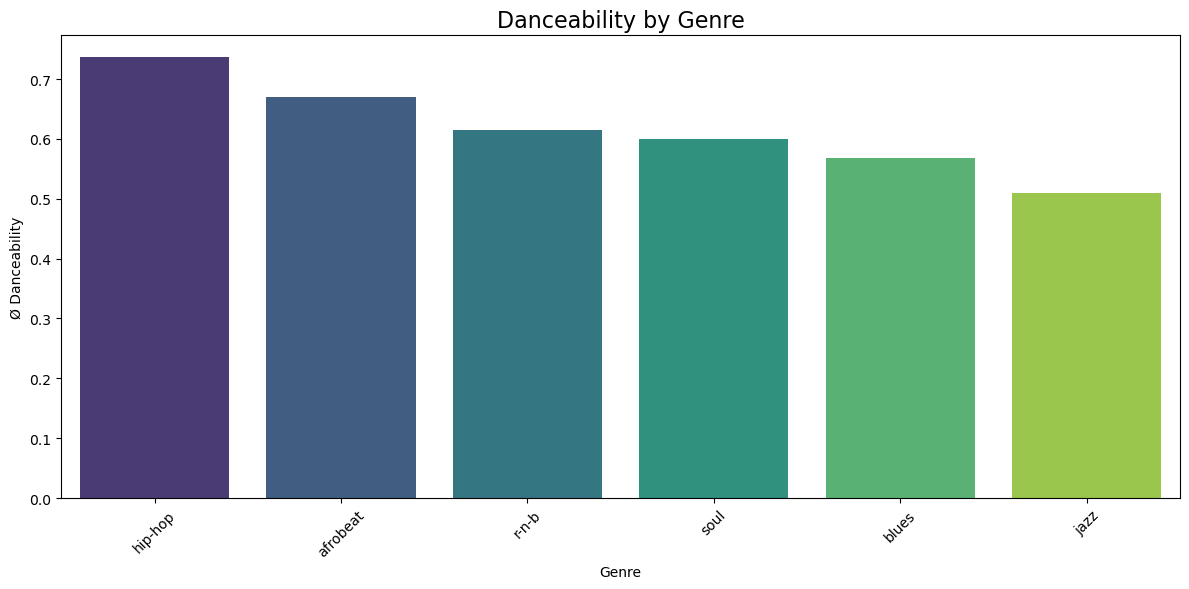

In [6]:
# adding the group
df_projekt = df_projekt.copy()
df_projekt['gruppe'] = df_projekt['track_genre'].apply(
    lambda x: ' African' if x == 'afrobeat' else ' Western Black'
)

# Analysis 1: danceabiliy
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['danceability'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Danceability by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø Danceability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_20156\677901393.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


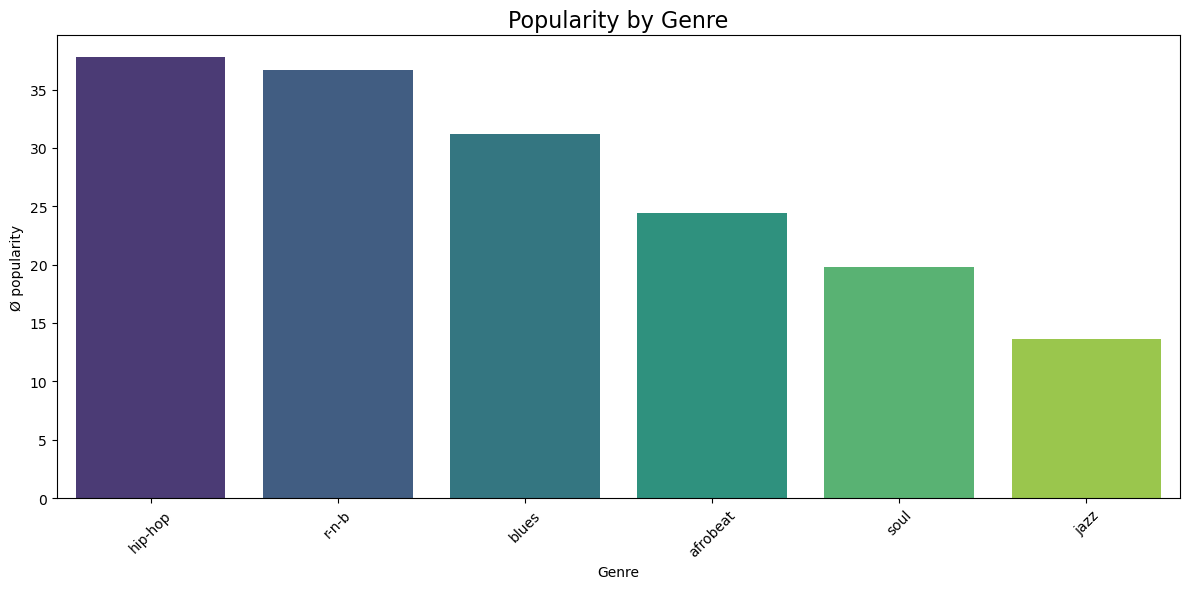

In [8]:
# Analysis 2: popularity
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Popularity by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Danceability & Popularity

**Does higher danceability in Afrobeats translate into increased streaming popularity compared to western genres?**

Hip-Hop ranks highest in danceability, with Afrobeat in second place. However, when looking at popularity, Hip-Hop still leads while Afrobeat drops to fourth place.
This suggests that higher danceability in Afrobeat does not automatically translate into higher streaming popularity. This gap may be explained by differences in external factors such as playlist placement and promotional investment may play a role. Western genres like Hip-Hop benefit from significantly more promotion and sponsorship.
For labels like Sony or UMG, this represents an opportunity: Afrobeat already has strong musical characteristics and investing more in its promotion could unlock significant streaming growth.

C:\Users\User\AppData\Local\Temp\ipykernel_20156\140536238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


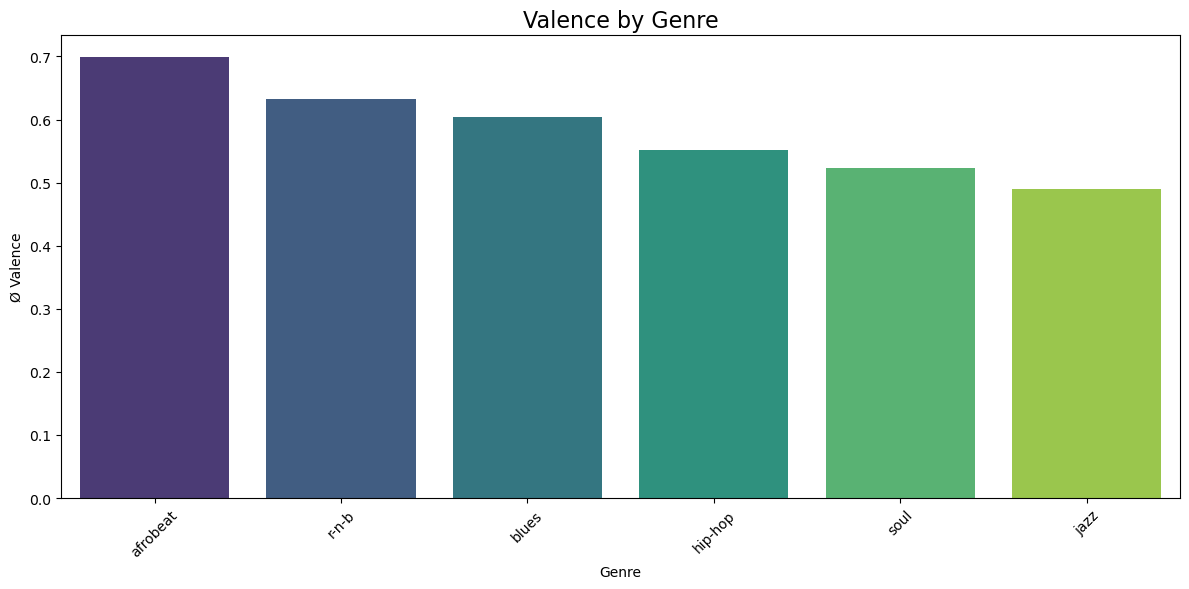

In [7]:
 # Analysis 3 : Valence
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['valence'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Valence by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø Valence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Valence

**Do higher valence levles in Afrobeats correlate with increased streaming popularity?**

No, Afrobeat has the highest valence but not the highest popularity. This reveals a gap between musical quality and streaming success in the music industry. Hip-Hop remains the most popular genre despite lower valence scores.
This suggests that Afrobeat has strong potential for streaming growth. It's positive and uplifting sound could appeal to global audiences seeking feel-good music

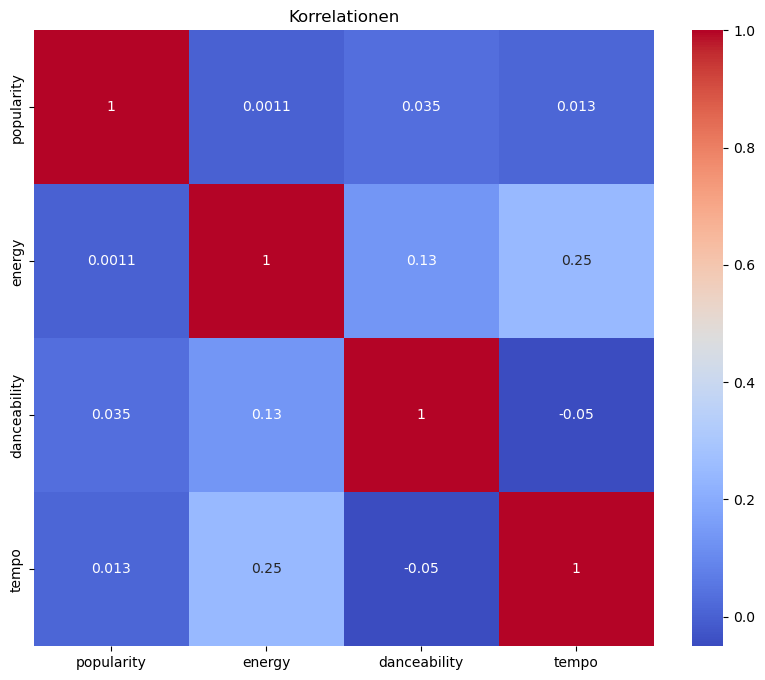

In [10]:

# correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df[['popularity','energy','danceability','tempo']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Korrelationen')
plt.show()



# Energy & Marketing Insight

**Does higher energy lead to increased popularity and what does this imply for music marketing strategies?**

Energy and popularity have a correlation of 0.0011 which means that there is no to little relation between them. This shows that higher energy does not lead to popularity in songs. For a song to be popular  music labels probably use marketing strategies such as  bulding a fan community, social media content to build the artist's brand.

C:\Users\User\AppData\Local\Temp\ipykernel_20156\2270492457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df_projekt,


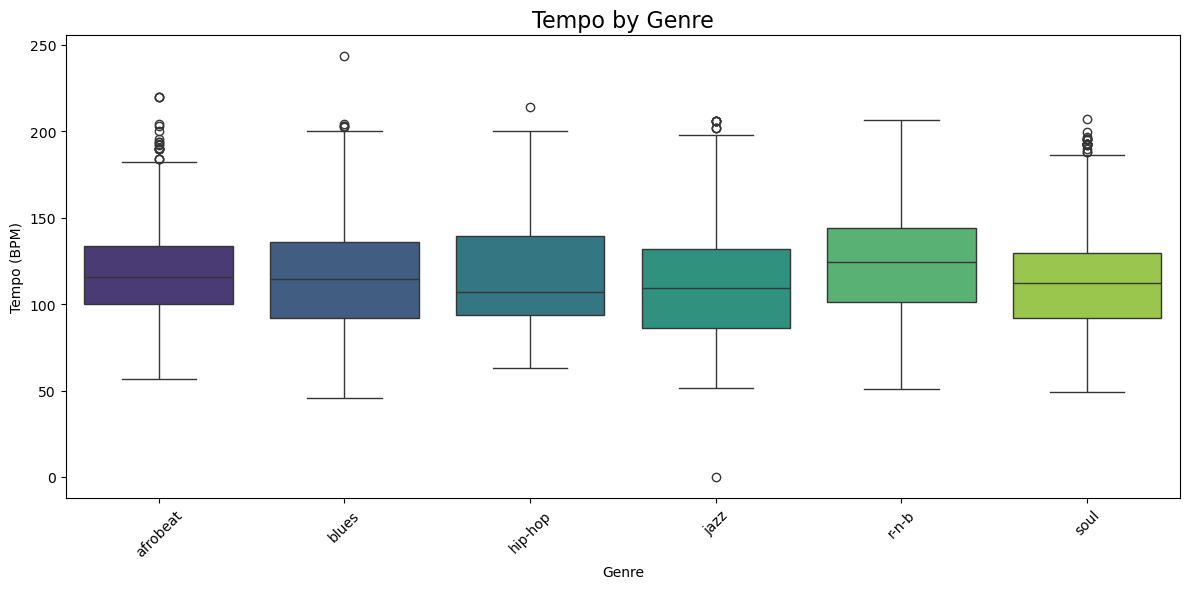

In [12]:
# Analysis 4 : tempo
plt.figure(figsize=(12, 6))
sns.boxplot(data= df_projekt, 
            x='track_genre', 
            y='tempo', 
            palette='viridis')
plt.title('Tempo by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Tempo (BPM)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tempo & Danceability

BPM (Beats Per Minute) measures the speed of a song. Most popular music falls between 100-140 BPM.
The boxplot shows that all genres have a similar median tempo between 110-125 BPM. Afrobeat has a consistent core tempo of approximately 120 BPM but shows several outliers above 180 BPM, indicating some unusually fast tracks.
The correlation between tempo and danceability is -0.05, meaning there is almost no relationship between the two. A song does not need a high tempo to be danceable.
This suggests that tempo alone does not drive streaming success. Instead, factors such as artist popularity and label investment in the artist itself may play a more significant role. For labels, this means that promoting the artist , not just the music , is key to streaming success.

C:\Users\User\AppData\Local\Temp\ipykernel_20156\4129895438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


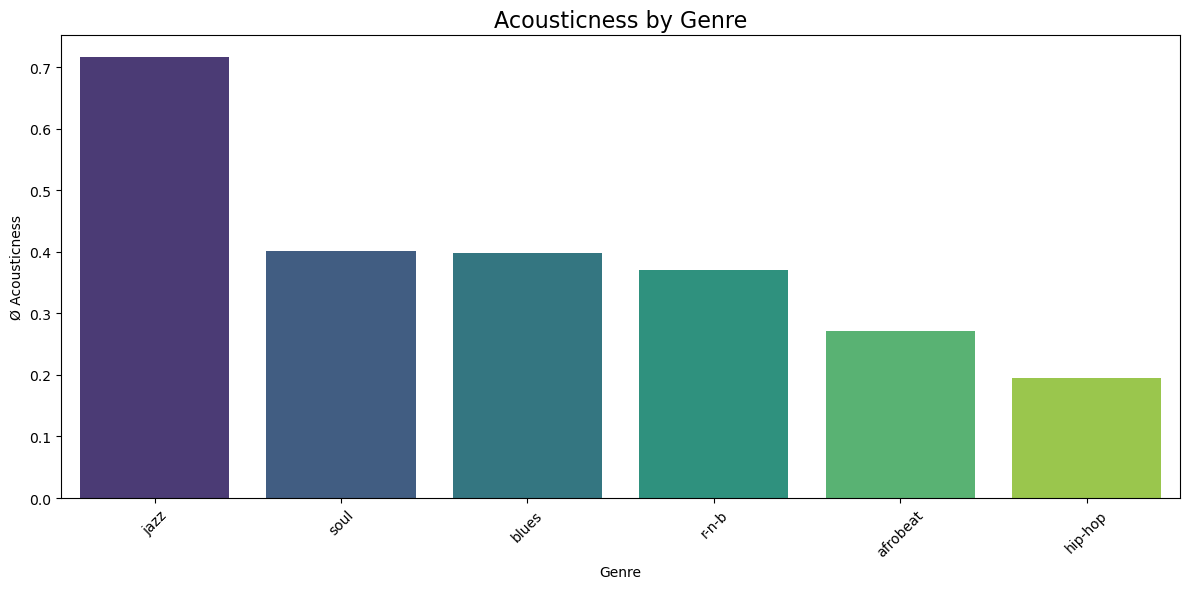

In [11]:
# Analysis 5: Acousticness 
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['acousticness'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Acousticness by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø Acousticness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# CSV export
df_projekt.to_csv('african_vs_western.csv', index=False)


# Acousticness

As an additional finding, Jazz shows the highest acousticness while Hip-Hop and Afrobeat are more electronically produced. This reflects the cultural origins of each genre.

# Underrepresentation

**Is Afrobeats underrepresented in streaming popularity relative to its audio characteristics compared to western genres?**

Afrobeat ranks 1st in valence and 2nd in danceability among all 6 genres. However, it only ranks 4th in streaming popularity.
This gap between strong audio characteristics and lower popularity suggests that Afrobeat is underrepresented on streaming platforms relative to its musical quality.Increasing platform exposure and visibility could bridge the gap between Afrobeat's musical quality and its streaming performance.

# Limitation

This analysis is limited by one african genre. Future research could include Amapiano and other African genres for more complete picture. The spotify dataset is from Kaggle which means that it  is also not up to day.

# Conclusion
This analysis shows that Afrobeat does differ from western genres in several audio characteristics. Afrobeat is among the other 5 genres rank number 1 in Valence, number 2 in Danceability but in popularity number 4. I then analyse the audio features which came to conclusion that audio features alone do not fully explain streaming success. Afrobeat's strong danceability and valence do not proportionally translate into higher popularity scores.This suggests that external factors ,such as playlist placement, market exposure, and promotional strategies play a significant role in determining streaming performance.Future research could expand this analysis by including additional African genres such as Amapiano or Afrobeats subgenres, as well as incorporating real-time streaming data to capture current trends.